In [1]:
from google.colab import files
uploaded=files.upload()

Saving netflix_titles_nov_2019.csv.zip to netflix_titles_nov_2019.csv.zip


In [2]:
import zipfile

with zipfile.ZipFile("netflix_titles_nov_2019.csv.zip", "r") as zip_ref:
    zip_ref.extractall()

print("Files extracted successfully!")

Files extracted successfully!


In [3]:
import os

print(os.listdir())

['.config', 'netflix_titles_nov_2019.csv', 'netflix_titles_nov_2019.csv.zip', 'sample_data']


In [4]:
import pandas as pd

df = pd.read_csv("netflix_titles_nov_2019.csv")

df.head()

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type
0,81193313,Chocolate,NaN,"Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...",South Korea,"November 30, 2019",2019,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",Brought together by meaningful meals in the pa...,TV Show
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,NaN,"November 30, 2019",2019,TV-G,67 min,"Documentaries, International Movies","From Sierra de las Minas to Esquipulas, explor...",Movie
2,81213894,The Zoya Factor,Abhishek Sharma,"Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...",India,"November 30, 2019",2019,TV-14,135 min,"Comedies, Dramas, International Movies",A goofy copywriter unwittingly convinces the I...,Movie
3,81082007,Atlantics,Mati Diop,"Mama Sane, Amadou Mbow, Ibrahima Traore, Nicol...","France, Senegal, Belgium","November 29, 2019",2019,TV-14,106 min,"Dramas, Independent Movies, International Movies","Arranged to marry a rich man, young Ada is cru...",Movie
4,80213643,Chip and Potato,NaN,"Abigail Oliver, Andrea Libman, Briana Buckmast...","Canada, United Kingdom",NaN,2019,TV-Y,2 Seasons,Kids' TV,"Lovable pug Chip starts kindergarten, makes ne...",TV Show


In [5]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (5837, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5837 entries, 0 to 5836
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       5837 non-null   int64 
 1   title         5837 non-null   object
 2   director      3936 non-null   object
 3   cast          5281 non-null   object
 4   country       5410 non-null   object
 5   date_added    5195 non-null   object
 6   release_year  5837 non-null   int64 
 7   rating        5827 non-null   object
 8   duration      5837 non-null   object
 9   listed_in     5837 non-null   object
 10  description   5837 non-null   object
 11  type          5837 non-null   object
dtypes: int64(2), object(10)
memory usage: 547.3+ KB


In [6]:
df.describe(include='all')

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type
count,5.837000e+03,5837,3936,5281,5410,5195,5837.000000,5827,5837,5837,5837,5837
unique,NaN,5780,3108,5087,527,1092,NaN,14,194,449,5829,2
top,NaN,Oh My Ghost,"Raúl Campos, Jan Suter",David Attenborough,United States,"November 1, 2019",NaN,TV-MA,1 Season,Documentaries,A surly septuagenarian gets another chance at ...,Movie
freq,NaN,3,18,18,1907,94,NaN,1937,1259,297,3,3939
mean,7.730079e+07,NaN,NaN,NaN,NaN,NaN,2013.688539,NaN,NaN,NaN,NaN,NaN
std,9.479777e+06,NaN,NaN,NaN,NaN,NaN,8.419088,NaN,NaN,NaN,NaN,NaN
min,2.698800e+05,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN,NaN
25%,8.004520e+07,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN,NaN
50%,8.016353e+07,NaN,NaN,NaN,NaN,NaN,2016.000000,NaN,NaN,NaN,NaN,NaN
75%,8.024188e+07,NaN,NaN,NaN,NaN,NaN,2018.000000,NaN,NaN,NaN,NaN,NaN


In [7]:
df.isnull().sum()

,0
show_id,0
title,0
director,1901
cast,556
country,427
date_added,642
release_year,0
rating,10
duration,0
listed_in,0


In [8]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

df.isnull().sum()

,0
show_id,0
title,0
director,0
cast,0
country,0
date_added,642
release_year,0
rating,0
duration,0
listed_in,0


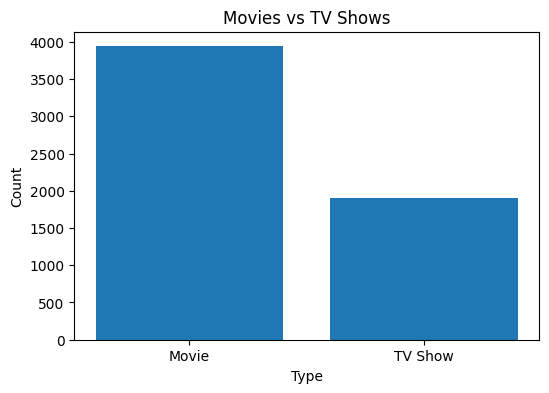

In [9]:
import matplotlib.pyplot as plt

type_count = df["type"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(type_count.index, type_count.values)

plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

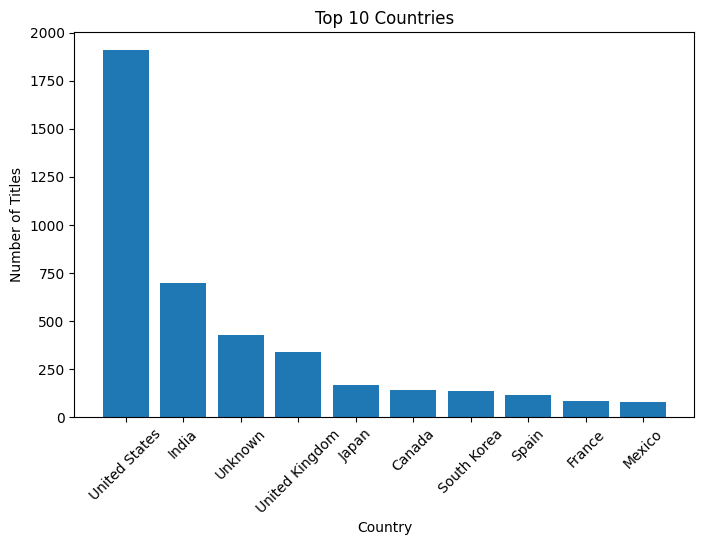

In [10]:
top_country = df["country"].value_counts().head(10)

plt.figure(figsize=(8,5))
plt.bar(top_country.index, top_country.values)

plt.xticks(rotation=45)
plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.show()

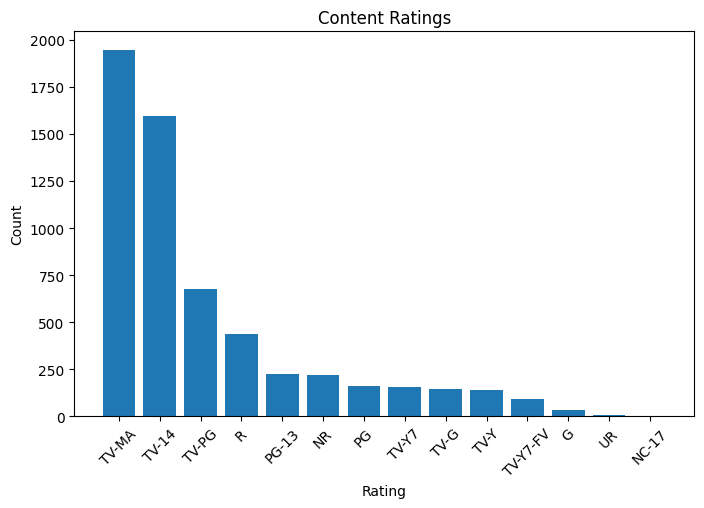

In [11]:
rating = df["rating"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(rating.index, rating.values)

plt.xticks(rotation=45)
plt.title("Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

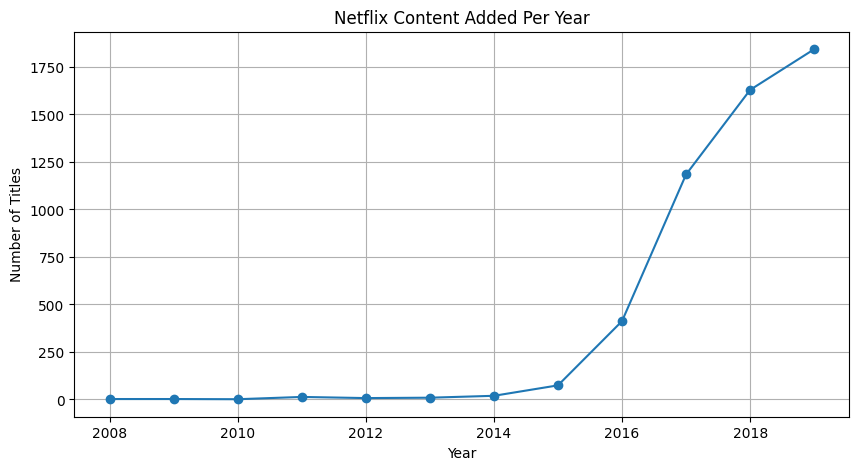

In [12]:
df["date_added"] = pd.to_datetime(df["date_added"])

df["year_added"] = df["date_added"].dt.year

year = df["year_added"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(year.index, year.values, marker="o")

plt.title("Netflix Content Added Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.grid()

plt.show()

In [13]:
numeric = df.select_dtypes(include=["number"])

numeric.corr()

,show_id,release_year,year_added
show_id,1.000000,0.536742,-0.04894
release_year,0.536742,1.000000,0.08569
year_added,-0.048940,0.085690,1.00000


In [14]:
df.to_csv("Netflix_EDA_Cleaned.csv", index=False)

print("Netflix_EDA_Cleaned.csv saved successfully!")

Netflix_EDA_Cleaned.csv saved successfully!


In [15]:
from google.colab import files
files.download("Netflix_EDA_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>